Races: (1125, 18)
Drivers: (861, 9)
Lap Times: (589081, 6)
Pit Stops: (11371, 7)
Constructors: (212, 5)

Races Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         1125 non-null   object
 7   url          1125 non-null   object
 8   fp1_date     1125 non-null   object
 9   fp1_time     1125 non-null   object
 10  fp2_date     1125 non-null   object
 11  fp2_time     1125 non-null   object
 12  fp3_date     1125 non-null   object
 13  fp3_time     1125 non-null   object
 14  quali_date   1125 non-null   object
 15  quali_time   1125 non-null   object
 16  sprint_date  1125 non-null   obje

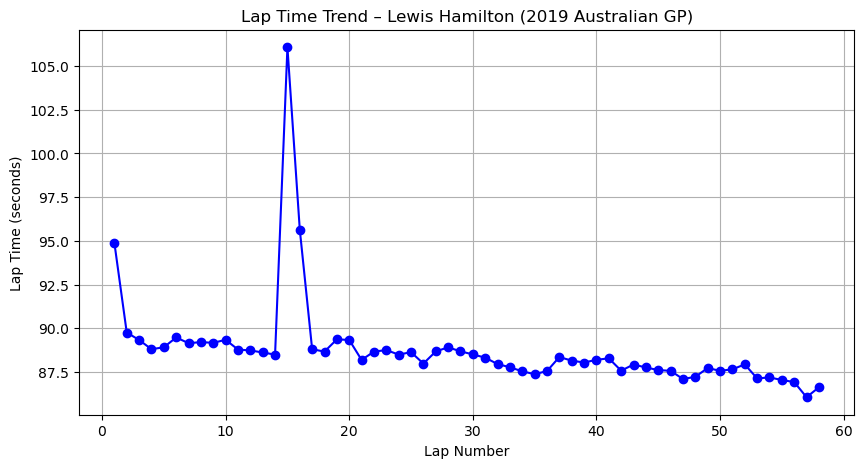

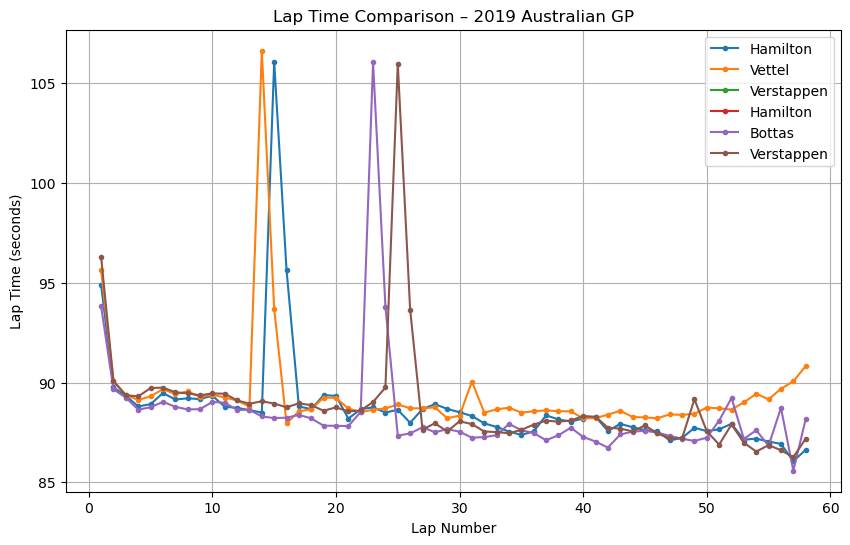

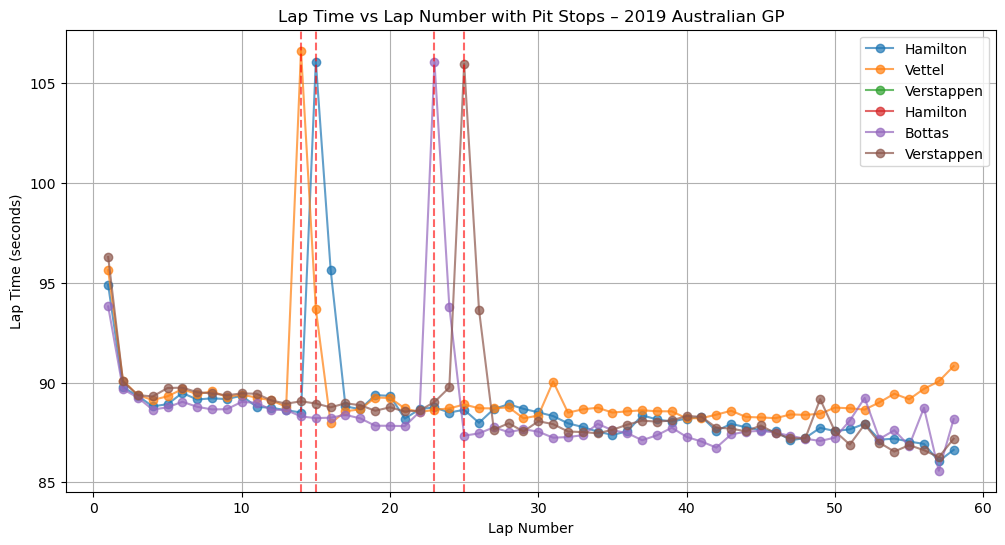

C:\Users\whuss\AppData\Local\Temp\ipykernel_3476\3871865617.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_lap_times, x='lap_time_sec', y='circuit_name', palette='viridis')


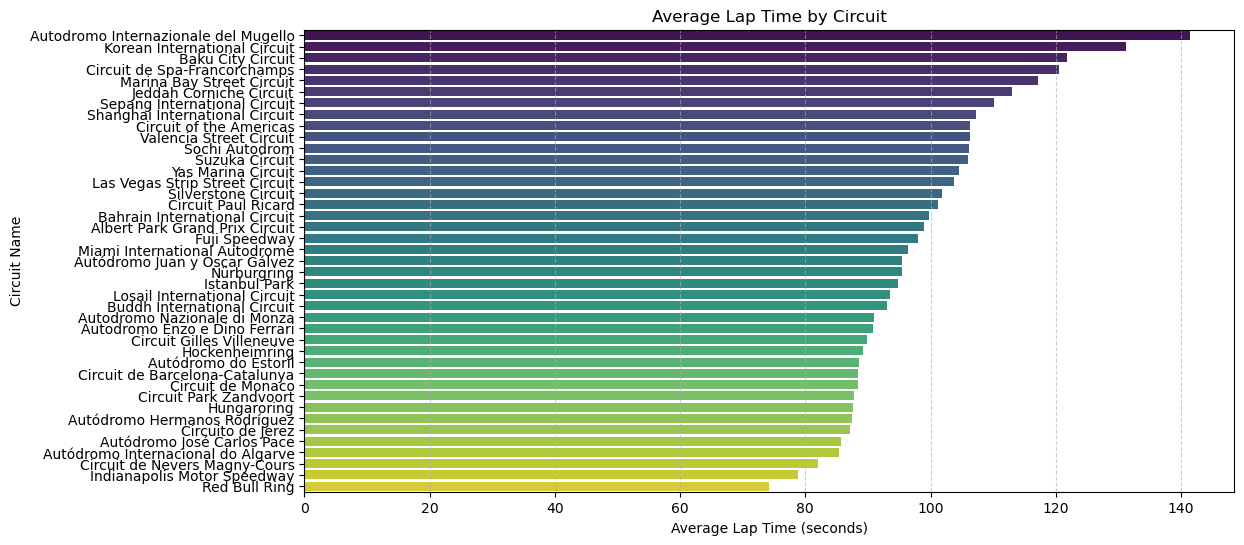

C:\Users\whuss\AppData\Local\Temp\ipykernel_3476\3871865617.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=driver_stats.head(15), x='mean', y='driver_name', palette='crest')


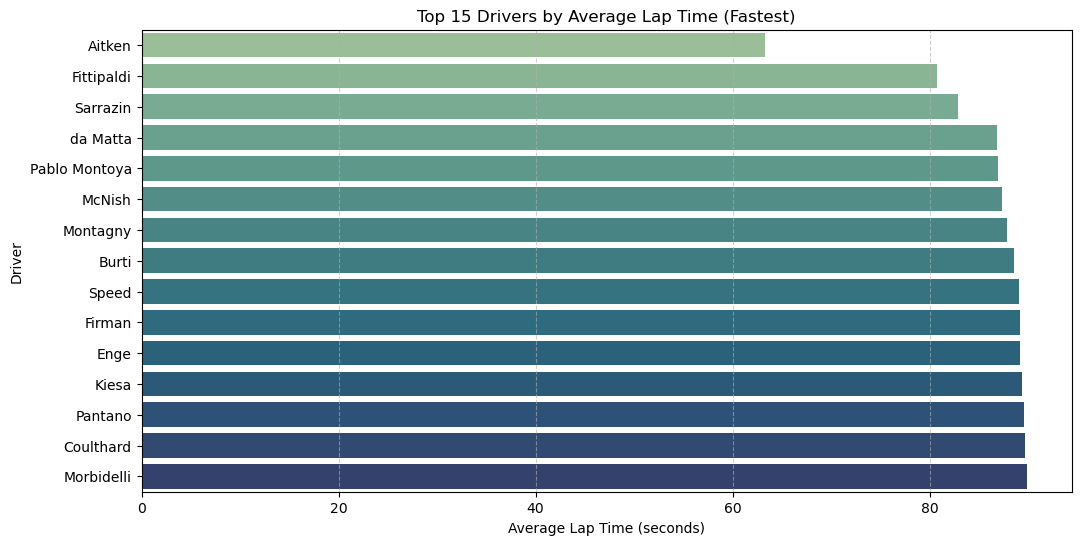

C:\Users\whuss\AppData\Local\Temp\ipykernel_3476\3871865617.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_stats.head(10), x='mean', y='constructor_name', palette='mako')


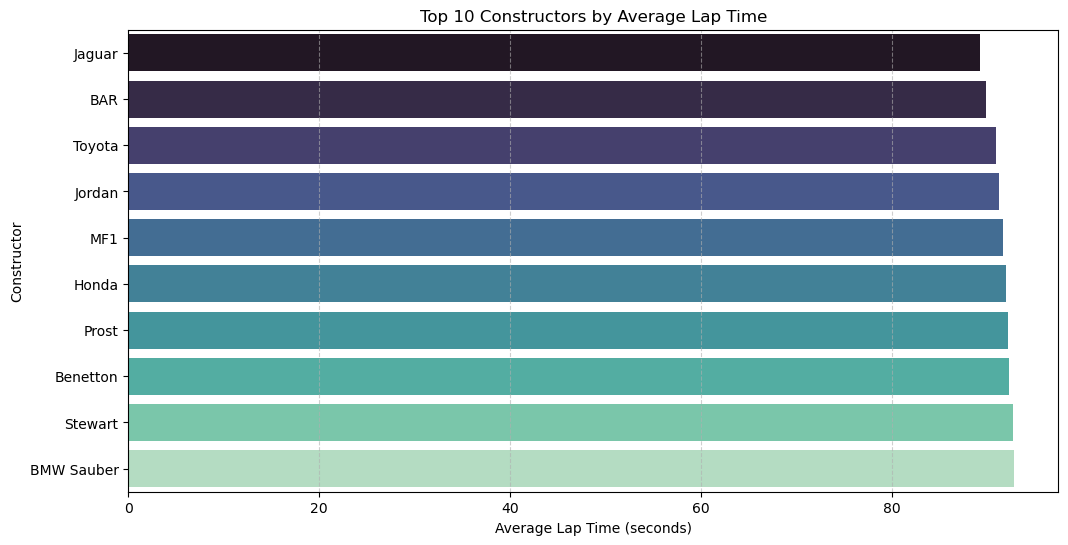

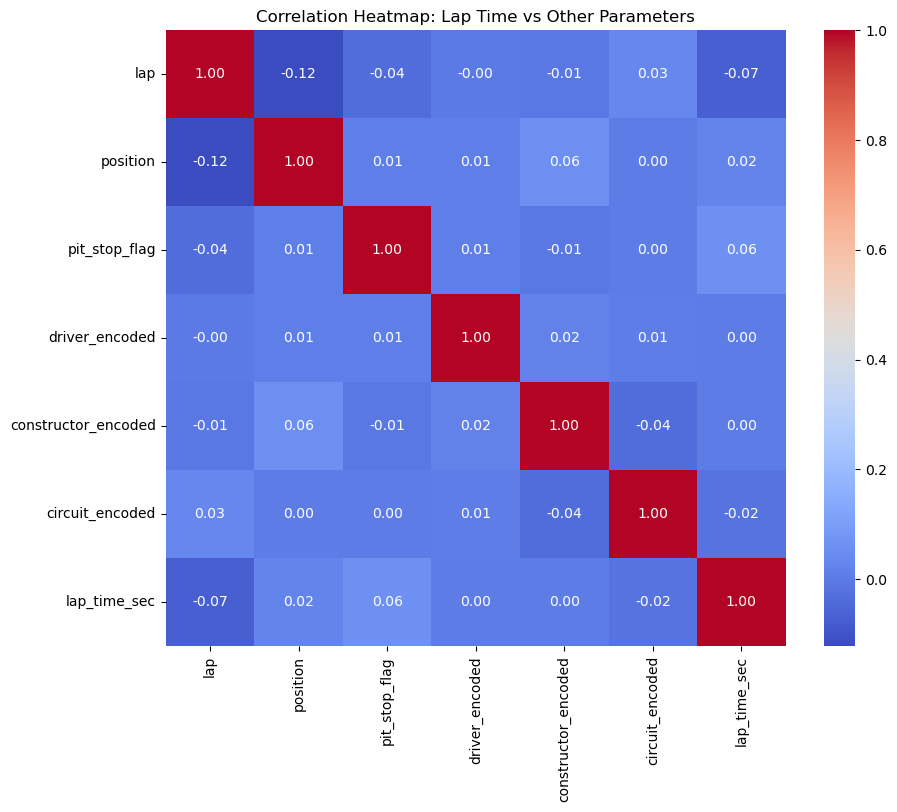


 ANOVA Test Results:
Driver effect p-value: 0.00000
Constructor effect p-value: 0.00000
Circuit effect p-value: 0.00000


In [2]:
#  Importing Libaraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

#  Loading Datasets

races = pd.read_csv('races.csv')
drivers = pd.read_csv('drivers.csv')
lap_times = pd.read_csv('lap_times.csv')
pit_stops = pd.read_csv('pit_stops.csv')
constructors = pd.read_csv('constructors.csv')
results = pd.read_csv('results.csv')
circuits = pd.read_csv('circuits.csv')

print("Races:", races.shape)
print("Drivers:", drivers.shape)
print("Lap Times:", lap_times.shape)
print("Pit Stops:", pit_stops.shape)
print("Constructors:", constructors.shape)
print("\nRaces Info:")
print(races.info(), "\n")
print("Drivers Info:")
print(drivers.info(), "\n")
print("Lap Times Info:")
print(lap_times.info(), "\n")
print("Pit Stops Info:")
print(pit_stops.info())

# milliseconds exists before using it
if 'milliseconds' not in lap_times.columns:
    print("'milliseconds' column missing in lap_times!")
else:
    lap_times['lap_time_sec'] = lap_times['milliseconds'] / 1000

# EDA- Analysis 
race_2019 = races[(races['year'] == 2019) & (races['name'] == 'Australian Grand Prix')]
race_id = race_2019['raceId'].values[0]
driver_id = drivers[drivers['surname'] == 'Hamilton']['driverId'].values[0]

hamilton_laps = lap_times[(lap_times['raceId'] == race_id) & (lap_times['driverId'] == driver_id)].copy()
hamilton_laps['lap_time_sec'] = hamilton_laps['milliseconds'] / 1000

plt.figure(figsize=(10,5))
plt.plot(hamilton_laps['lap'], hamilton_laps['lap_time_sec'], marker='o', color='blue')
plt.title("Lap Time Trend – Lewis Hamilton (2019 Australian GP)")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.grid(True)
plt.show()
# EDA(Race Position Analysis)

driver_names = ['Hamilton', 'Bottas', 'Vettel', 'Verstappen']
driver_ids = drivers[drivers['surname'].isin(driver_names)][['driverId', 'surname']]

plt.figure(figsize=(10,6))
for _, row in driver_ids.iterrows():
    drv_id = row['driverId']
    drv_name = row['surname']
    laps = lap_times[(lap_times['raceId']==race_id) & (lap_times['driverId']==drv_id)].copy()
    laps['lap_time_sec'] = laps['milliseconds'] / 1000
    plt.plot(laps['lap'], laps['lap_time_sec'], marker='.', label=drv_name)

plt.title("Lap Time Comparison – 2019 Australian GP")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()

# EDA(Pit Stop Analysis)
lap_times['lap_time_sec'] = lap_times['milliseconds'] / 1000

if 'milliseconds' in pit_stops.columns:
    pit_stops = pit_stops.rename(columns={'milliseconds': 'pit_duration_ms'})
else:
    pit_stops['pit_duration_ms'] = np.nan  # placeholder if missing

lap_data = pd.merge(lap_times, pit_stops[['raceId', 'driverId', 'lap', 'pit_duration_ms']], 
                    on=['raceId', 'driverId', 'lap'], how='left')
lap_data['pit_stop_flag'] = lap_data['pit_duration_ms'].notnull().astype(int)

plt.figure(figsize=(12,6))
for _, row in driver_ids.iterrows():
    drv_id = row['driverId']
    drv_name = row['surname']
    data = lap_data[(lap_data['raceId']==race_id) & (lap_data['driverId']==drv_id)]
    plt.plot(data['lap'], data['lap_time_sec'], marker='o', label=drv_name, alpha=0.7)
    for pit in data[data['pit_stop_flag']==1]['lap']:
        plt.axvline(x=pit, color='red', linestyle='--', alpha=0.6)

plt.title('Lap Time vs Lap Number with Pit Stops – 2019 Australian GP')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

# EDA(Circuit Analysis)

races_circuits = races.merge(circuits, on='circuitId', how='left')
lap_data = lap_times.merge(races_circuits[['raceId', 'name_x', 'year', 'name_y', 'country']],
                           on='raceId', how='left')
lap_data.rename(columns={'name_x': 'race_name', 'name_y': 'circuit_name'}, inplace=True)
lap_data['lap_time_sec'] = lap_data['milliseconds'] / 1000

avg_lap_times = lap_data.groupby('circuit_name')['lap_time_sec'].mean().reset_index()
avg_lap_times = avg_lap_times.sort_values(by='lap_time_sec', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=avg_lap_times, x='lap_time_sec', y='circuit_name', palette='viridis')
plt.title('Average Lap Time by Circuit')
plt.xlabel('Average Lap Time (seconds)')
plt.ylabel('Circuit Name')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

#  EDA(Driver & Constructor)
merged = lap_times.merge(results[['raceId', 'driverId', 'constructorId']], on=['raceId', 'driverId'], how='left')
merged = merged.merge(drivers[['driverId', 'surname']], on='driverId', how='left')
merged = merged.merge(constructors[['constructorId', 'name']], on='constructorId', how='left')
merged.rename(columns={'surname': 'driver_name', 'name': 'constructor_name'}, inplace=True)
merged['lap_time_sec'] = merged['milliseconds'] / 1000

driver_stats = merged.groupby('driver_name')['lap_time_sec'].agg(['mean', 'std']).reset_index().sort_values(by='mean')

plt.figure(figsize=(12,6))
sns.barplot(data=driver_stats.head(15), x='mean', y='driver_name', palette='crest')
plt.title('Top 15 Drivers by Average Lap Time (Fastest)')
plt.xlabel('Average Lap Time (seconds)')
plt.ylabel('Driver')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

team_stats = merged.groupby('constructor_name')['lap_time_sec'].agg(['mean', 'std']).reset_index().sort_values(by='mean')

plt.figure(figsize=(12,6))
sns.barplot(data=team_stats.head(10), x='mean', y='constructor_name', palette='mako')
plt.title('Top 10 Constructors by Average Lap Time')
plt.xlabel('Average Lap Time (seconds)')
plt.ylabel('Constructor')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


# EDA (Corrleation & Significance Test)
# =====================================================================
races_circuits = races.merge(circuits, on='circuitId', how='left')
lap_data = lap_times.merge(races_circuits[['raceId','name_x','year','circuitId','country']], on='raceId', how='left')
lap_data.rename(columns={'name_x':'race_name'}, inplace=True)
lap_data['lap_time_sec'] = lap_data['milliseconds'] / 1000

lap_data = lap_data.merge(results[['raceId','driverId','constructorId']], on=['raceId','driverId'], how='left')
lap_data = lap_data.merge(drivers[['driverId','surname']], on='driverId', how='left')
lap_data = lap_data.merge(constructors[['constructorId','name']], on='constructorId', how='left')
lap_data.rename(columns={'surname':'driver','name':'constructor'}, inplace=True)

# Add pit stop flag safely
if 'pit_duration_ms' not in pit_stops.columns:
    pit_stops['pit_duration_ms'] = np.nan

lap_data = lap_data.merge(pit_stops[['raceId','driverId','lap','pit_duration_ms']], on=['raceId','driverId','lap'], how='left')
lap_data['pit_stop_flag'] = lap_data['pit_duration_ms'].notnull().astype(int)

encoder = LabelEncoder()
lap_data['driver_encoded'] = encoder.fit_transform(lap_data['driver'])
lap_data['constructor_encoded'] = encoder.fit_transform(lap_data['constructor'])
lap_data['circuit_encoded'] = encoder.fit_transform(lap_data['circuitId'].astype(str))

features = ['lap','position','pit_stop_flag','driver_encoded','constructor_encoded','circuit_encoded','lap_time_sec']
data_corr = lap_data[features].dropna()

corr = data_corr.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Lap Time vs Other Parameters')
plt.show()

# ANOVA Significance Tests
anova_driver = stats.f_oneway(
    *[lap_data.loc[lap_data['driver']==d, 'lap_time_sec'].dropna() for d in lap_data['driver'].unique()[:10]]
)
anova_constructor = stats.f_oneway(
    *[lap_data.loc[lap_data['constructor']==t, 'lap_time_sec'].dropna() for t in lap_data['constructor'].unique()[:10]]
)
anova_circuit = stats.f_oneway(
    *[lap_data.loc[lap_data['circuitId']==c, 'lap_time_sec'].dropna() for c in lap_data['circuitId'].unique()[:10]]
)


print("\n ANOVA Test Results:")
print(f"Driver effect p-value: {anova_driver.pvalue:.5f}")
print(f"Constructor effect p-value: {anova_constructor.pvalue:.5f}")
print(f"Circuit effect p-value: {anova_circuit.pvalue:.5f}")


In [3]:
# Merge all the key components
races_circuits = races.merge(circuits, on='circuitId', how='left')
lap_data = lap_times.merge(races_circuits[['raceId','year','circuitId','country']], on='raceId', how='left')
lap_data['lap_time_sec'] = lap_data['milliseconds'] / 1000

lap_data = lap_data.merge(results[['raceId','driverId','constructorId']], on=['raceId','driverId'], how='left')
lap_data = lap_data.merge(drivers[['driverId','surname']], on='driverId', how='left')
lap_data = lap_data.merge(constructors[['constructorId','name']], on='constructorId', how='left')
lap_data.rename(columns={'surname':'driver','name':'constructor'}, inplace=True)

# Pit stop flag
if 'milliseconds' in pit_stops.columns:
    pit_stops = pit_stops.rename(columns={'milliseconds': 'pit_duration_ms'})
else:
    pit_stops['pit_duration_ms'] = np.nan

lap_data = lap_data.merge(pit_stops[['raceId','driverId','lap','pit_duration_ms']], on=['raceId','driverId','lap'], how='left')
lap_data['pit_stop_flag'] = lap_data['pit_duration_ms'].notnull().astype(int)

print("✅ Data merged successfully:", lap_data.shape)

#  ENCODE CATEGORICAL VARIABLES
# ------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
lap_data['driver_encoded'] = encoder.fit_transform(lap_data['driver'])
lap_data['constructor_encoded'] = encoder.fit_transform(lap_data['constructor'])
lap_data['circuit_encoded'] = encoder.fit_transform(lap_data['circuitId'].astype(str))


#  LAP-BASED FEATURES
# ------------------------------------------------------------
lap_data = lap_data.sort_values(by=['raceId','driverId','lap'])
lap_data['prev_lap_time'] = lap_data.groupby(['raceId','driverId'])['lap_time_sec'].shift(1)
lap_data['lap_diff_time'] = lap_data['lap_time_sec'] - lap_data['prev_lap_time']
lap_data['degradation_rate'] = lap_data['lap_diff_time'] / lap_data['prev_lap_time']
lap_data[['prev_lap_time','lap_diff_time','degradation_rate']] = lap_data[
    ['prev_lap_time','lap_diff_time','degradation_rate']
].fillna(0)

#  PIT STOP FEATURES
# ------------------------------------------------------------
lap_data['laps_since_last_pit'] = lap_data.groupby(['raceId','driverId'])['pit_stop_flag'].cumsum()


#  CIRCUIT FEATURES
# ------------------------------------------------------------
avg_circuit_lap = lap_data.groupby('circuit_encoded')['lap_time_sec'].mean().reset_index()
avg_circuit_lap.rename(columns={'lap_time_sec': 'avg_circuit_lap_time'}, inplace=True)
lap_data = lap_data.merge(avg_circuit_lap, on='circuit_encoded', how='left')


#  DRIVER & CONSTRUCTOR STATISTICS
# ------------------------------------------------------------
driver_avg = lap_data.groupby('driver_encoded')['lap_time_sec'].agg(['mean','std']).reset_index()
driver_avg.rename(columns={'mean':'driver_mean_lap','std':'driver_std_lap'}, inplace=True)
lap_data = lap_data.merge(driver_avg, on='driver_encoded', how='left')

team_avg = lap_data.groupby('constructor_encoded')['lap_time_sec'].agg(['mean','std']).reset_index()
team_avg.rename(columns={'mean':'team_mean_lap','std':'team_std_lap'}, inplace=True)
lap_data = lap_data.merge(team_avg, on='constructor_encoded', how='left')
lap_data['race_progress_pct'] = lap_data['lap'] / lap_data.groupby(['raceId','driverId'])['lap'].transform('max')
lap_data['is_final_lap'] = (lap_data['race_progress_pct'] > 0.95).astype(int)

#  HANDLE MISSING VALUES
# ------------------------------------------------------------
lap_data = lap_data.fillna(0)

#  FINAL FEATURE SET
# ------------------------------------------------------------
selected_features = [
    'lap', 'position', 'pit_stop_flag',
    'prev_lap_time', 'lap_diff_time', 'degradation_rate',
    'laps_since_last_pit', 'driver_encoded', 'constructor_encoded',
    'circuit_encoded', 'avg_circuit_lap_time',
    'driver_mean_lap', 'driver_std_lap',
    'team_mean_lap', 'team_std_lap',
    'race_progress_pct', 'is_final_lap'
]

X = lap_data[selected_features]
y = lap_data['lap_time_sec']


✅ Data merged successfully: (589081, 15)


Training: 471264, Testing: 117817

✅ Linear Regression Results: R²=0.9540, RMSE=16.8306, MAE=5.5827

✅ Random Forest Results: R²=0.9669, RMSE=14.2919, MAE=0.4598

✅ Gradient Boosting Results: R²=0.9800, RMSE=11.1054, MAE=1.0153

✅ XGBoost Results: R²=0.8804, RMSE=27.1527, MAE=1.3569

 Model Performance Comparison:
               Model        R²       RMSE       MAE
0  Linear Regression  0.954049  16.830567  5.582719
1      Random Forest  0.966866  14.291938  0.459813
2  Gradient Boosting  0.979994  11.105402  1.015314
3            XGBoost  0.880403  27.152668  1.356937


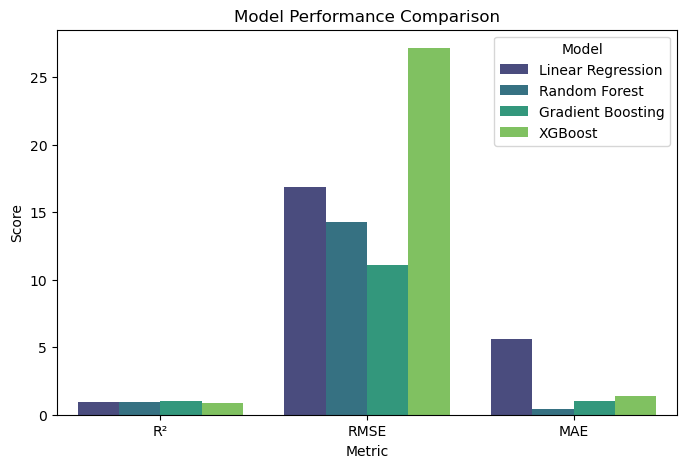


🏆 Best Model: Gradient Boosting (R² = 0.9800)
💾 Best model saved as best_model.pkl


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost not installed, skipping it.")
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training: {X_train.shape[0]}, Testing: {X_test.shape[0]}")
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, n_jobs=-1)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({"Model": name, "R²": r2, "RMSE": rmse, "MAE": mae})
    print(f"\n✅ {name} Results: R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

 COMPARE MODELS
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
print("\n Model Performance Comparison:")
print(results_df)

plt.figure(figsize=(8,5))
sns.barplot(data=results_df.melt(id_vars='Model', var_name='Metric', value_name='Score'),
            x='Metric', y='Score', hue='Model', palette='viridis')
plt.title("Model Performance Comparison")
plt.show()


# ------------------------------------------------------------
best_model = results_df.sort_values(by="R²", ascending=False).iloc[0]
print(f"\n Best Model: {best_model['Model']} (R² = {best_model['R²']:.4f})")



In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Random Forest Hyperparameter Grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

rf_model = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best CV R² Score:", rf_grid.best_score_)

# Final Model
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

print("\nRandom Forest Final Results:")
print("R²:", r2_score(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE:", mean_absolute_error(y_test, rf_pred))
from sklearn.ensemble import GradientBoostingRegressor

# ---------------------------
# Gradient Boosting Hyperparameter Grid
# ---------------------------

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [1.0]
}

gb_model = GradientBoostingRegressor(random_state=42)

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_params,
    cv=2,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print("Best CV R² Score:", gb_grid.best_score_)

# Final Model Prediction
gb_best = gb_grid.best_estimator_

gb_pred = gb_best.predict(X_test)

print("\nGradient Boosting Final Results:")
print("R²:", r2_score(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("MAE:", mean_absolute_error(y_test, gb_pred))



Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² Score: 0.94557428111859

Random Forest Final Results:
R²: 0.974956217622833
RMSE: 12.42518462258568
MAE: 2.728608760947596
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV R² Score: 0.9554448445780439

Gradient Boosting Final Results:
R²: 0.9798964669363561
RMSE: 11.132407216241738
MAE: 1.288645889168889
